In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot  as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('heart_disease.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA and Data Cleaning & Preprocessing

# 1. Shape

In [4]:
df.shape

(918, 12)

# 2. Columns

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

# 3. Info

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


# 4. Descriptive Summary

In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


# 5. Null Values

In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

# 6. Duplicates

In [9]:
print(df.duplicated().sum())

0


# 7. DataTypes

In [10]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

# Data Visualization

# 1. Histogram for Numeric Variables 

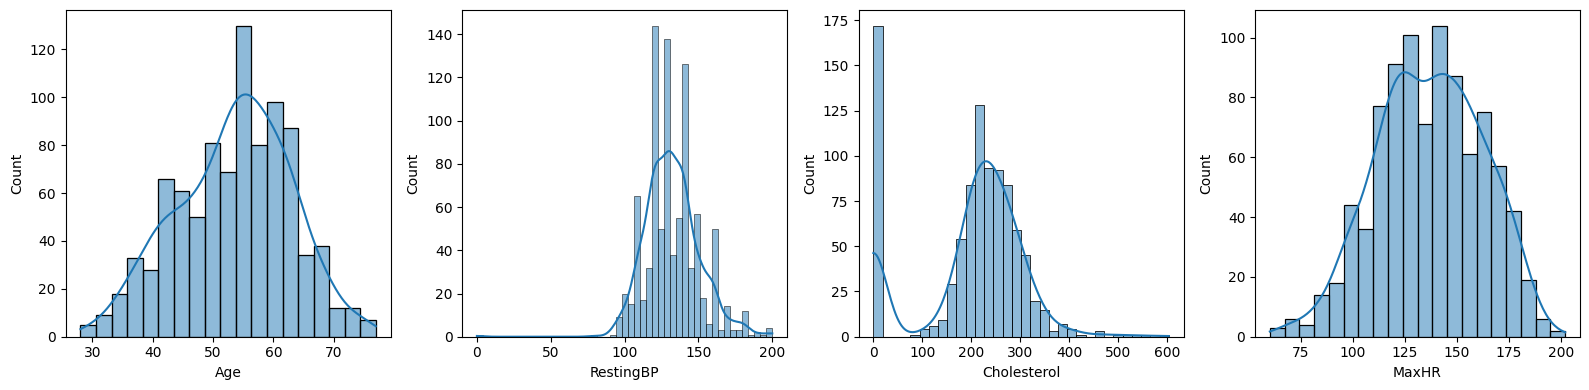

In [46]:
plt.figure(figsize=(16,4))
def plotting(var, num):
    plt.subplot(1, 4, num)
    sns.histplot(df[var], kde=True)
    
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

plt.tight_layout()
plt.show()

# 2. Count Plot for Categorical Values in comparison with HeartDisease

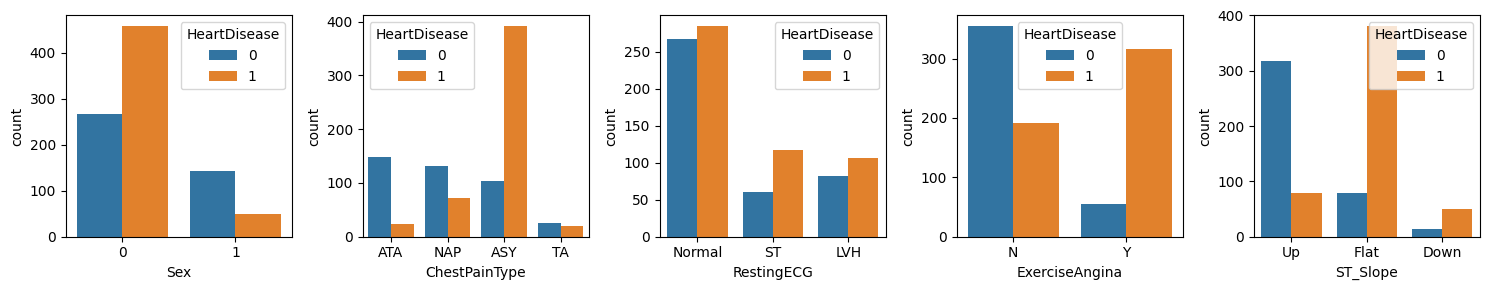

In [48]:
plt.figure(figsize=(15,3))
def plotting(var, num):
    plt.subplot(1, 5, num)
    sns.countplot(data=df, x=var, hue='HeartDisease')

plotting('Sex', 1)
plotting('ChestPainType', 2)
plotting('RestingECG', 3)
plotting('ExerciseAngina', 4)
plotting('ST_Slope', 5)

plt.tight_layout()
plt.show()


# 3. Box Plots for Numeric Features

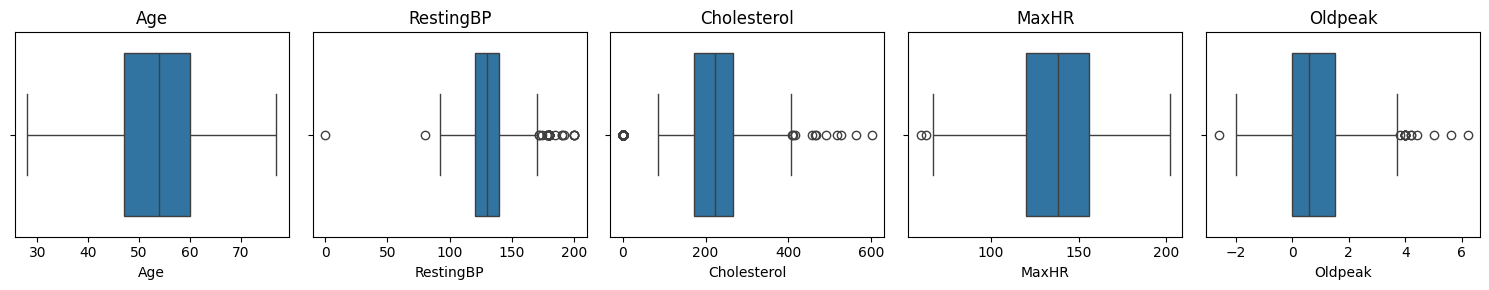

In [44]:
plt.figure(figsize=(15,3))

def plotting(var, num):
    plt.subplot(1, 5, num)
    sns.boxplot(x=df[var])
    plt.title(var)

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plotting('Oldpeak', 5)

plt.tight_layout()
plt.show()

# Data Cleaning & Preprocessing

# 1. Heat Map

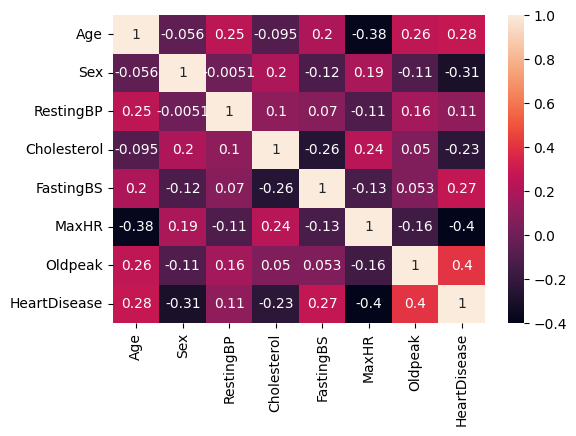

In [54]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

# 2. Map sex into 0 and 1 for M and F

In [17]:
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


# 3. Creating dummies

In [18]:
df_encode = pd.get_dummies(df,drop_first=True)
df_encode.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0.0,0,True,False,False,True,False,False,False,True
1,49,1,160,180,0,156,1.0,1,False,True,False,True,False,False,True,False
2,37,0,130,283,0,98,0.0,0,True,False,False,False,True,False,False,True
3,48,1,138,214,0,108,1.5,1,False,False,False,True,False,True,True,False
4,54,0,150,195,0,122,0.0,0,False,True,False,True,False,False,False,True


# Feature Engineering & Feature Extraction

# 1. Standard Scaling

In [21]:
from sklearn.preprocessing import StandardScaler
cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df_encode[cols] = scaler.fit_transform(df_encode[cols])

In [22]:
df_encode.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.410909,0.825070,0,1.382928,-0.832432,0,True,False,False,True,False,False,False,True
1,-0.478484,1,1.491752,-0.171961,0,0.754157,0.105664,1,False,True,False,True,False,False,True,False
2,-1.751359,0,-0.129513,0.770188,0,-1.525138,-0.832432,0,True,False,False,False,True,False,False,True
3,-0.584556,1,0.302825,0.139040,0,-1.132156,0.574711,1,False,False,False,True,False,True,True,False
4,0.051881,0,0.951331,-0.034755,0,-0.581981,-0.832432,0,False,True,False,True,False,False,False,True


# Model Training

In [23]:
from sklearn.model_selection import train_test_split

In [55]:
X = df_encode.drop('HeartDisease',axis=1)
y = df_encode['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Logistic Regression

In [71]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: \t", round(accuracy,2))

# Confusion matrix
Confusion_Matrix = confusion_matrix(y_test,y_pred)
print("\n Confusion_Matrix: \n\n",Confusion_Matrix)

# Classification Report
print("\n Classification Report: \n",classification_report(y_test,y_pred))

Accuracy: 	 0.85

 Confusion_Matrix: 

 [[67 10]
 [17 90]]

 Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184

